In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.decomposition import PCA

In [ ]:
df_train = pd.read_csv("E:/100 Days Machine Learning/Data Sets/mnist_train.csv.csv")

In [ ]:
df_train

In [ ]:
plt.imshow(df_train.iloc[99,1:].values.reshape(28,28)), print(df_train.iloc[99,:2])
plt.show()

In [ ]:
x = df_train.iloc[:,1:]
y = df_train.iloc[:,0]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [ ]:
x_train.shape, x_test.shape

In [ ]:
knn = KNeighborsClassifier()

knn.fit(x_train, y_train)

In [ ]:
import time
start = time.time()
y_pred = knn.predict(x_test)

print(time.time() - start)

In [ ]:
accuracy_score(y_test, y_pred)

# Using PCA

Step 1. Standardising Data

In [ ]:
scaler = StandardScaler()

In [ ]:
x_train_trf = scaler.fit_transform(x_train)
x_test_trf = scaler.transform(x_test)

In [ ]:
pca = PCA(n_components=100)

In [ ]:
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

In [ ]:
x_train_trf.shape

Step 2. Training model on Data

In [ ]:
knn = KNeighborsClassifier()

knn.fit(x_train_trf, y_train)

In [ ]:
y_pred = knn.predict(x_test_trf)

In [ ]:
accuracy_score(y_test, y_pred)

In [ ]:
df = []

for i in range(1, 785):
    pca = PCA(n_components= i)
    x_train_trf = pca.fit_transform(x_train)
    x_test_trf = pca.transform(x_test)
    
    knn = KNeighborsClassifier()
    knn.fit(x_train_trf, y_train)
    y_pred = knn.predict(x_test_trf)
    
    df.append({
        "accuracy":accuracy_score(y_test,y_pred),
        "n_components":i
    })
    
df = pd.DataFrame(df)

In [ ]:
df.max()

Step 3. Visualizing Data

In [30]:
# transforming to 2D coordinate system

pca = PCA(n_components=2)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

In [34]:
y_train_trf = y_train.astype(str)
fig = px.scatter(x= x_train_trf[:,0],
                 y= x_train_trf[:,1],
                 color= y_train_trf,
                 color_discrete_sequence= px.colors.qualitative.G10)
fig.show()

In [46]:
# transforming to 3D coordinates

pca = PCA(n_components=3)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

y_train_trf = y_train.astype(str)
fig = px.scatter_3d(x= x_train_trf[:,0], y= x_train_trf[:,1],z= x_train_trf[:,2],color= y_train_trf)
fig.show()

In [41]:
# Eigen values
pca.explained_variance_

array([335506.57620544, 244807.10511442, 212051.0345165 ])

In [42]:
# Eigen vectors
pca.components_

array([[-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.]], shape=(3, 784))

**Finding Optimum no. of principle components :** when variance covers > 90
%

In [47]:
pca = PCA(n_components=None)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

In [48]:
pca.components_

array([[-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]], shape=(784, 784))

In [49]:
pca.explained_variance_

array([3.35506576e+05, 2.44807105e+05, 2.12051035e+05, 1.85066153e+05,
       1.68000246e+05, 1.48918349e+05, 1.12510833e+05, 9.93294844e+04,
       9.51402644e+04, 7.99789771e+04, 7.18729893e+04, 7.02954186e+04,
       5.86421706e+04, 5.77978479e+04, 5.44160811e+04, 5.10942763e+04,
       4.54324809e+04, 4.40877557e+04, 4.06349678e+04, 3.95293850e+04,
       3.69465718e+04, 3.51694514e+04, 3.31919492e+04, 3.14980784e+04,
       3.03792806e+04, 2.86216441e+04, 2.79878549e+04, 2.66233147e+04,
       2.54782977e+04, 2.38073682e+04, 2.26921743e+04, 2.17431167e+04,
       2.07130988e+04, 2.02157853e+04, 1.92920932e+04, 1.85377184e+04,
       1.74405813e+04, 1.67269421e+04, 1.61818599e+04, 1.59519157e+04,
       1.55375765e+04, 1.52480605e+04, 1.43023838e+04, 1.35853438e+04,
       1.31721648e+04, 1.28124366e+04, 1.23858612e+04, 1.19793099e+04,
       1.14757321e+04, 1.09198370e+04, 1.07891523e+04, 1.05497976e+04,
       1.00392867e+04, 9.83967219e+03, 9.58435154e+03, 9.24819162e+03,
      

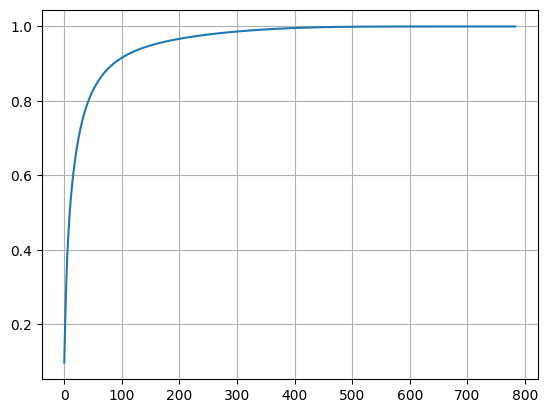

In [59]:
x = pca.explained_variance_ratio_.cumsum()

plt.plot(x)
plt.grid()
plt.show()